In [12]:
import torch 
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(
    root="/datasets/apollo2506/eurosat-dataset/EuroSAT",
    transform=transform
)

In [16]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)- train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [17]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 10)

model.load_state_dict(torch.load("model/best_model.pth"))
model.eval()

Grad-CAM works best on last convolution layer.

In [9]:
target_layers = [model.layer4[-1]]

In [41]:
images, labels = next(iter(val_loader))
images = images.to(device)

input_tensor = images[0].unsqueeze(0)

Generate Heatmap

In [42]:
cam = GradCAM(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor)[0]

Prepare Image for Overlay

We need the original image in numpy format

In [43]:
img = images[0].cpu().permute(1,2,0).numpy()

Overlay heatmap

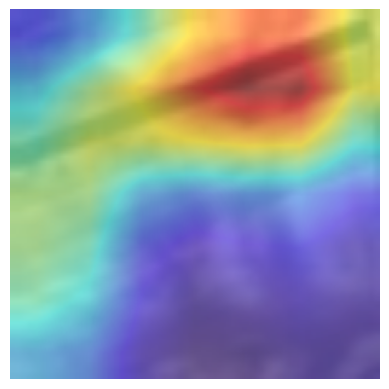

In [44]:
visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")
plt.show()

Normalize Image for Visualization

Grad-CAM expects values between 0–1.

In [45]:
img = img / img.max()

In [46]:
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

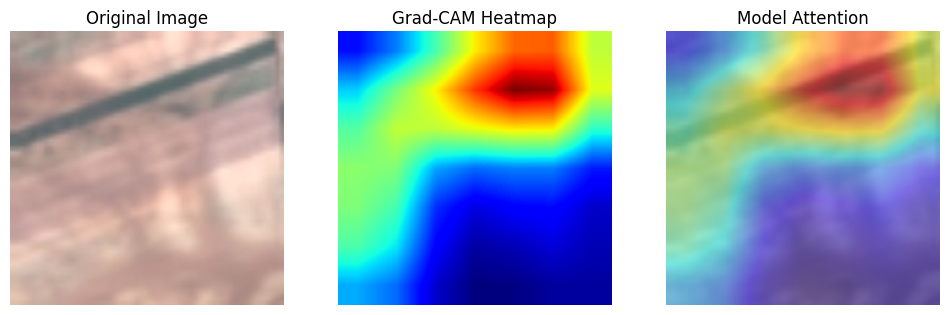

In [47]:
plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(cam_image)
plt.title("Model Attention")
plt.axis("off")

plt.show()

The heatmap shows where the model looked before predicting.

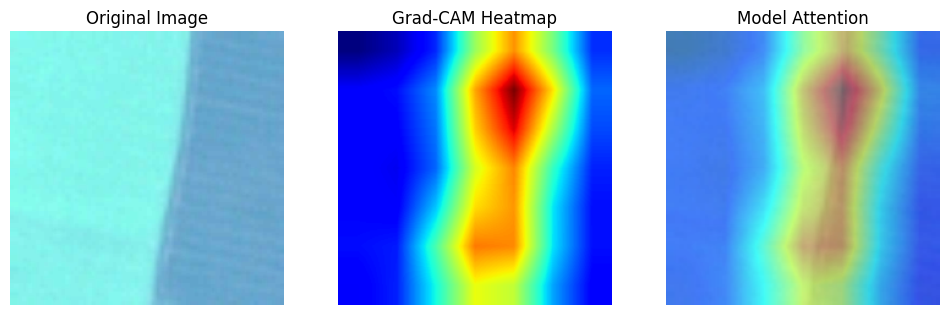

In [48]:
input_tensor = images[2].unsqueeze(0)
grayscale_cam = cam(input_tensor=input_tensor)[0]
img = images[2].cpu().permute(1,2,0).numpy()
img = img / img.max()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(cam_image)
plt.title("Model Attention")
plt.axis("off")

plt.show()

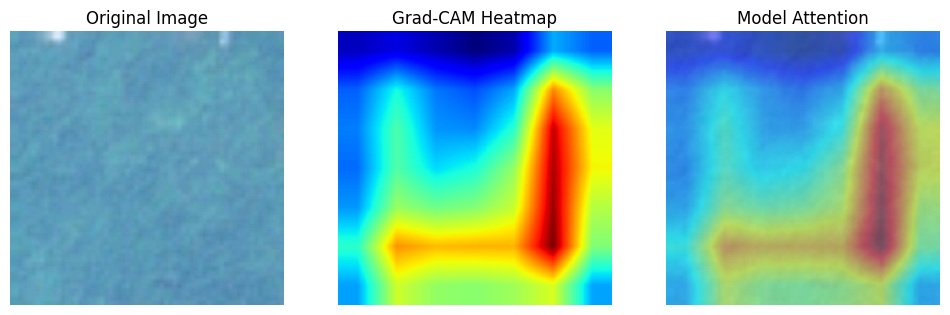

In [50]:
input_tensor = images[1].unsqueeze(0)
grayscale_cam = cam(input_tensor=input_tensor)[0]
img = images[1].cpu().permute(1,2,0).numpy()
img = img / img.max()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(cam_image)
plt.title("Model Attention")
plt.axis("off")

plt.show()

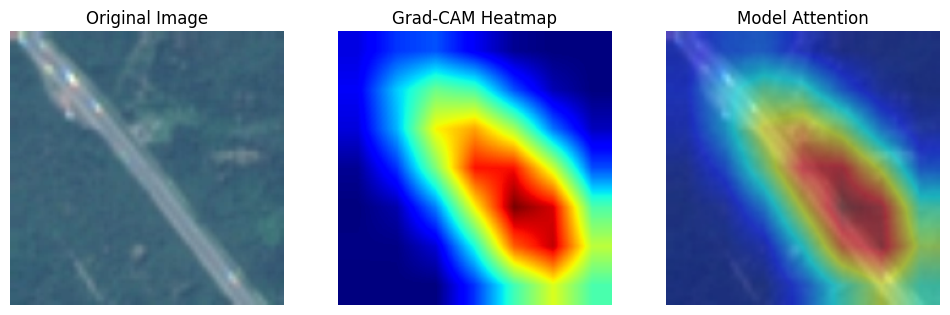

In [51]:
input_tensor = images[3].unsqueeze(0)
grayscale_cam = cam(input_tensor=input_tensor)[0]
img = images[3].cpu().permute(1,2,0).numpy()
img = img / img.max()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(cam_image)
plt.title("Model Attention")
plt.axis("off")

plt.show()

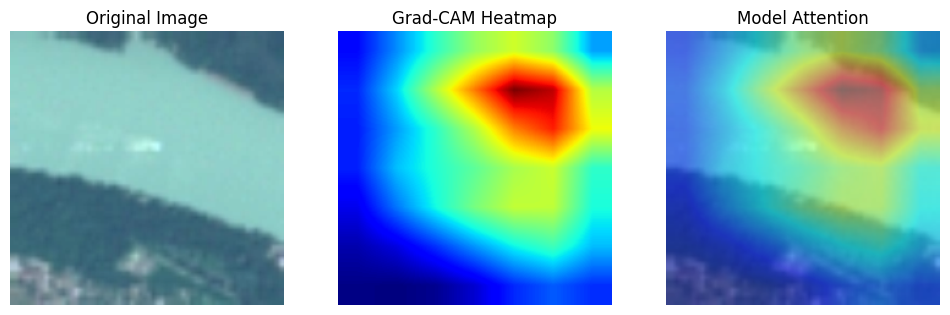

In [52]:
input_tensor = images[4].unsqueeze(0)
grayscale_cam = cam(input_tensor=input_tensor)[0]
img = images[4].cpu().permute(1,2,0).numpy()
img = img / img.max()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(cam_image)
plt.title("Model Attention")
plt.axis("off")

plt.show()

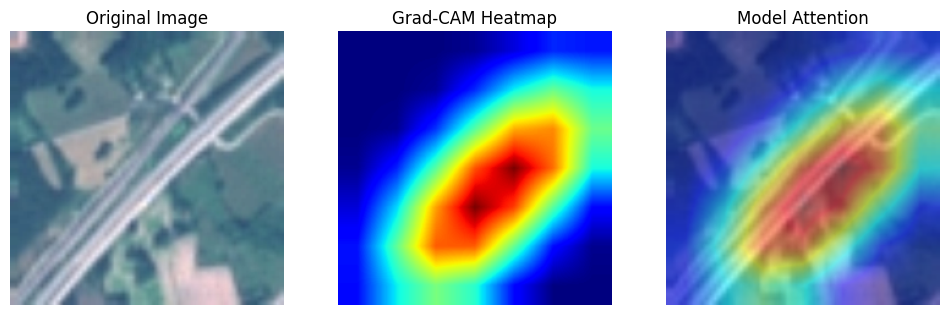

In [53]:
input_tensor = images[5].unsqueeze(0)
grayscale_cam = cam(input_tensor=input_tensor)[0]
img = images[5].cpu().permute(1,2,0).numpy()
img = img / img.max()
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(12,4))

# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1,3,3)
plt.imshow(cam_image)
plt.title("Model Attention")
plt.axis("off")

plt.show()